In [124]:
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN, HDBSCAN
import matplotlib.pyplot as plt
import plotly.express as px
from astropy.coordinates import SkyCoord
import astropy.units as u
from sklearn.metrics import silhouette_samples
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [125]:
df0 = pd.read_csv(r"C:\Users\nicob\One Drive Uniandes\OneDrive - Universidad de los Andes\Doctorado\proyecto\clusterization_project\data\DatosTotales\gaia_parallax5.csv")
df1 = pd.read_csv(r"C:\Users\nicob\One Drive Uniandes\OneDrive - Universidad de los Andes\Doctorado\proyecto\clusterization_project\data\datos_resultados_modularizado\datos_clusterizados_todos_5d_trace.csv")
df2 = pd.read_csv(r"C:\Users\nicob\One Drive Uniandes\OneDrive - Universidad de los Andes\Doctorado\proyecto\clusterization_project\data\DatosTotales\base_emily_hunt.csv")

In [126]:
df1['division'] = df1['coordenada_ra'].astype(str) + "_" + df1['coordenada_dec'].astype(str)
nueva_numeracion = np.arange(0,len(df1['division'].unique()))
d_nueva_numeracion = dict(zip(df1['division'].unique(),nueva_numeracion))
df1['numeracion'] = df1['division'].map(d_nueva_numeracion)
df1['cluster'] = (df1['grupo'].astype(str) + df1['numeracion'].astype(str)).astype(int)
nueva_numeracion = np.arange(0,len(df1['division'].unique()))
d_nueva_numeracion = dict(zip(df1['division'].unique(),nueva_numeracion))
df1['numeracion'] = df1['division'].map(d_nueva_numeracion)
df1['cluster'] = (df1['grupo'].astype(str) + df1['numeracion'].astype(str)).astype(int)

In [127]:
# ids0 = list(set(df0['source_id'].unique()).intersection(df2['GaiaDR3'].unique()))
ids = list(set(df2['GaiaDR3'].unique()).intersection(df1['source_id'].unique()))

In [128]:
print(len(ids), len(df2), len(df2[df2["Plx"]>10]), len(df1))

2646 1291929 2698 398944


In [129]:
df2[df2['Name'].isin(["HSC_396",'HSC_759'])]['Plx'].describe()

count    506.000000
mean      10.061184
std        1.334903
min        6.589078
25%        9.166299
50%       10.080378
75%       10.903735
max       13.830850
Name: Plx, dtype: float64

In [130]:
df2['cluster'] = np.where(df2['Name']=='Melotte_111', 7, np.where(df2['Name']=='Melotte_25', 8, -11111))
dfm = df1.merge(df2[df2['Name'].isin(["Melotte_25", "Melotte_111","HSC_396",'HSC_759'])][["cluster","Name","GaiaDR3",'Gmag', 'BPmag', 'RPmag',]], how='outer', right_on=['cluster','GaiaDR3'], left_on=['cluster','source_id'], indicator=True)

In [131]:
dfm2 = df1.merge(df2[df2['Name'].isin(["Melotte_25", "Melotte_111","HSC_396",'HSC_759'])][["cluster","Name","GaiaDR3",'Gmag', 'BPmag', 'RPmag',]], how='inner', right_on=['GaiaDR3'], left_on=['source_id'], indicator=True)

In [132]:
dfm2['present_in_sample'] = dfm2['ConteoAgrupaciones']/dfm2['PresenteEnMuestras']

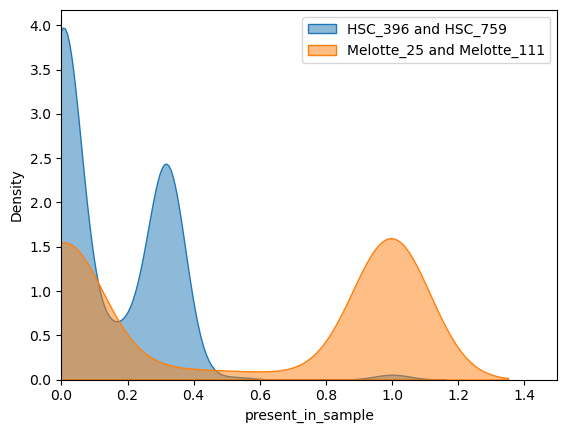

In [133]:
import seaborn as sns
dfm2hc = dfm2[dfm2['Name'].isin(["HSC_396",'HSC_759'])]
dfm2ot = dfm2[dfm2['Name'].isin(["Melotte_25","Melotte_111"])]
sns.kdeplot(dfm2hc, x='present_in_sample', label="HSC_396 and HSC_759", fill=True, alpha=0.5)
sns.kdeplot(dfm2ot, x='present_in_sample', label="Melotte_25 and Melotte_111", fill=True, alpha=0.5)
plt.legend()
plt.xlim(0,1.5)
plt.savefig("../figures/proportion_clustering_HSC.png")

In [134]:
dfm["phot_g_mean_mag"] = np.where(dfm['Gmag'].notna(), dfm['Gmag'], dfm['phot_g_mean_mag'])
dfm["bp_rp"] = np.where(dfm['BPmag'].notna() & dfm['RPmag'].notna(), dfm['BPmag'] - dfm['RPmag'], dfm['bp_rp'])
dfm['present_in_sample'] = np.where(dfm['ConteoAgrupaciones'].notna() & dfm['PresenteEnMuestras'].notna(), dfm['ConteoAgrupaciones']/dfm['PresenteEnMuestras'], np.nan)

In [135]:
df3 = pd.read_csv(r"C:\Users\nicob\One Drive Uniandes\OneDrive - Universidad de los Andes\Doctorado\proyecto\clusterization_project\data\DatosTotales\base_emily_hunt_comparisson.csv")

In [136]:
dfhyades2 = dfm[dfm['cluster']==8]
df_coma = dfm[dfm['cluster']==7]

left_only
both
right_only


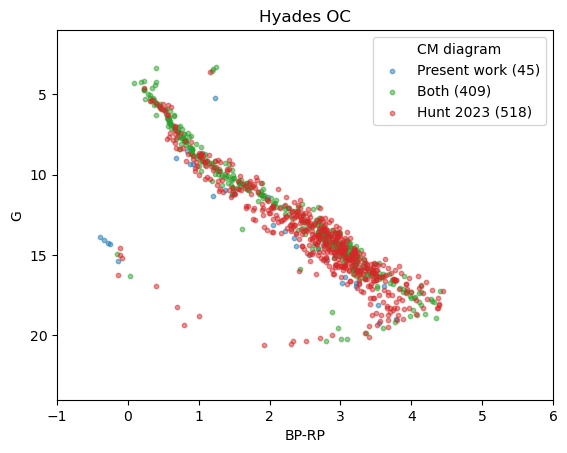

In [137]:
# Colores para el indicador de merge: left_only = trabajo presente, both = ambos, right_only = trabajo citado
merge_colors = {
    'left_only': 'tab:blue',
    'both': 'tab:green',
    'right_only': 'tab:red'
}
merge_labels = {
    'left_only': 'Present work',
    'both': 'Both',
    'right_only': 'Hunt 2023'
}

for merge_key, color in merge_colors.items():
    print(merge_key)
    subset_merge = dfhyades2[(dfhyades2['_merge'] == merge_key)]
    if merge_key == "right_only":
        s = 10,
        alpha = 0.5
    else:
        s = 10,
        alpha = 0.5
    if not subset_merge.empty:
        count = len(subset_merge)
        plt.scatter(subset_merge['bp_rp'], subset_merge['phot_g_mean_mag'],
                    color=color,
                    label=f"{merge_labels[merge_key]} ({count})",
                    s=s,
                    alpha=alpha)

plt.xlabel('BP-RP')
plt.ylabel('G')
plt.title(f'Hyades OC')
plt.legend(title='CM diagram')
plt.xlim(-1, 6)
plt.ylim(1, 24)
plt.gca().invert_yaxis()
plt.savefig("../figures/comparacion_hyades.png")
plt.show()

In [138]:
dfm2['both'] = np.where(((dfm2['Name']=='Melotte_25')&(dfm2['cluster_y']==8))|((dfm2['Name']=='Melotte_111')&(dfm2['cluster_y']==7)), 1, 0)
# dfm2[dfm2['Name'].isin(["Melotte_25", "Melotte_111"])]
dfm2['both'].value_counts()

both
1    1169
0     268
Name: count, dtype: int64

<Axes: xlabel='present_in_sample', ylabel='Density'>

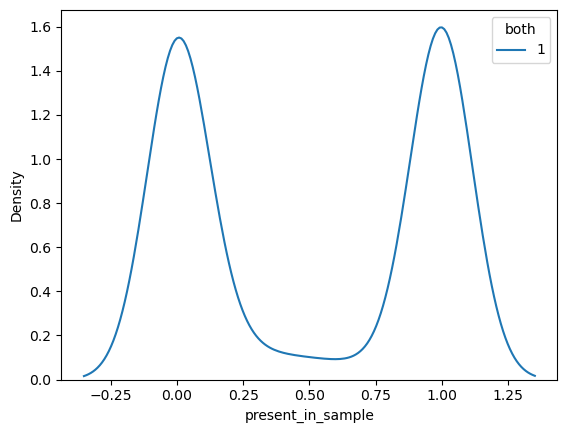

In [139]:
sns.kdeplot(data = dfm2[dfm2['Name'].isin(["Melotte_25", "Melotte_111"])], x='present_in_sample', hue='both')

left_only
both
right_only


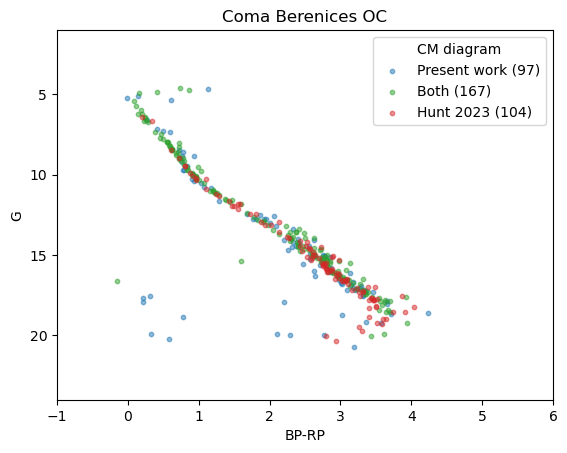

In [140]:
# Colores para el indicador de merge: left_only = trabajo presente, both = ambos, right_only = trabajo citado
merge_colors = {
    'left_only': 'tab:blue',
    'both': 'tab:green',
    'right_only': 'tab:red'
}
merge_labels = {
    'left_only': 'Present work',
    'both': 'Both',
    'right_only': 'Hunt 2023'
}

for merge_key, color in merge_colors.items():
    print(merge_key)
    subset_merge = df_coma[(df_coma['_merge'] == merge_key)]
    if not subset_merge.empty:
        count = len(subset_merge)
        plt.scatter(subset_merge['bp_rp'], subset_merge['phot_g_mean_mag'],
                    color=color,
                    label=f"{merge_labels[merge_key]} ({count})",
                    s=10,
                    alpha=0.5)

plt.xlabel('BP-RP')
plt.ylabel('G')
plt.title(f'Coma Berenices OC')
plt.legend(title='CM diagram')
plt.xlim(-1, 6)
plt.ylim(1, 24)
plt.gca().invert_yaxis()
plt.savefig("../figures/comparacion_coma.png")
plt.show()

In [141]:
dfm2 = dfm[dfm['Name'].isin(["HSC_396",'HSC_759'])]

In [142]:
def calculate_cluster_radius(
    df: pd.DataFrame,
    cluster_col: str = 'cluster',
    coord_cols: list = None,
    metrics: list = None
) -> pd.DataFrame:
    """
    Calcula métricas de radio y dispersión espacial para cada clúster.
    
    Utiliza un sistema de coordenadas cartesianas x, y, z (en parsecs)
    derivadas de coordenadas esféricas ICRS para capturar la geometría
    real de los clústers estelares.
    
    Args:
        df: DataFrame con datos de estrellas.
        cluster_col: Nombre de la columna de clústers.
        coord_cols: Lista de columnas de coordenadas [x, y, z].
                   Default: ['x_pc', 'y_pc', 'z_pc'].
        metrics: Lista de métricas a calcular.
                Default: ['mean', 'median', 'std', 'rms', 'effective_radius'].
    
    Returns:
        DataFrame con columnas: cluster, radio_mean, radio_median,
        radio_std, radio_rms, radius_effective.
        
    Raises:
        ValueError: Si las columnas de coordenadas no existen.
    """
    if coord_cols is None:
        coord_cols = ['x_pc', 'y_pc', 'z_pc']
    
    if metrics is None:
        metrics = ['mean', 'median', 'std', 'rms', 'effective_radius']
    
    # Validar que existan las columnas
    missing_cols = [col for col in coord_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Columnas no encontradas: {missing_cols}")
    
    df_valido = df[df[cluster_col] != -1].copy()
    resultados = []
    
    for cluster_id, grupo in df_valido.groupby(cluster_col):
        fila_resultado = {cluster_col: cluster_id}
        
        # Calcular centroide del clúster
        centroide = grupo[coord_cols].mean().values
        
        # Calcular distancias euclideas desde el centroide
        distancias = np.linalg.norm(
            grupo[coord_cols].values - centroide,
            axis=1
        )
        
        # Calcular métricas solicitadas
        if 'mean' in metrics:
            fila_resultado['radio_mean'] = np.mean(distancias)
        
        if 'median' in metrics:
            fila_resultado['radio_median'] = np.median(distancias)
        
        if 'std' in metrics:
            fila_resultado['radio_std'] = np.std(distancias)
        
        if 'rms' in metrics:
            # RMS considerando también la distancia desde el centro galáctico
            distancias_rms = np.sqrt(grupo[coord_cols].pow(2).sum(axis=1))
            fila_resultado['radio_rms'] = np.mean(distancias_rms)
        
        if 'effective_radius' in metrics:
            # Radio que encierra el 50% de las estrellas del clúster
            fila_resultado['radius_effective'] = np.percentile(distancias, 50)
        
        resultados.append(fila_resultado)
    
    return pd.DataFrame(resultados)

In [143]:
df2_analisis = df2[(df2['Name'].isin(["Melotte_25","Melotte_111","HSC_396",'HSC_759']))&(df2['Plx']>0)]
coords = SkyCoord(ra=df2_analisis['RA_ICRS'].values * u.degree,
                  dec=df2_analisis['DE_ICRS'].values * u.degree,
                  distance=(1000/df2_analisis['Plx']).values * u.pc,
                  frame='icrs')
df2_analisis['x_pc'] = coords.cartesian.x.value
df2_analisis['y_pc'] = coords.cartesian.y.value
df2_analisis['z_pc'] = coords.cartesian.z.value

C:\Users\nicob\AppData\Local\Temp\ipykernel_26896\4076352750.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2_analisis['x_pc'] = coords.cartesian.x.value
C:\Users\nicob\AppData\Local\Temp\ipykernel_26896\4076352750.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2_analisis['y_pc'] = coords.cartesian.y.value
C:\Users\nicob\AppData\Local\Temp\ipykernel_26896\4076352750.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_

In [144]:
radius_metrics = calculate_cluster_radius(
    df2_analisis,
    cluster_col='Name',
    coord_cols=['x_pc', 'y_pc', 'z_pc'],
    metrics=['mean', 'median', 'std', 'effective_radius']
)

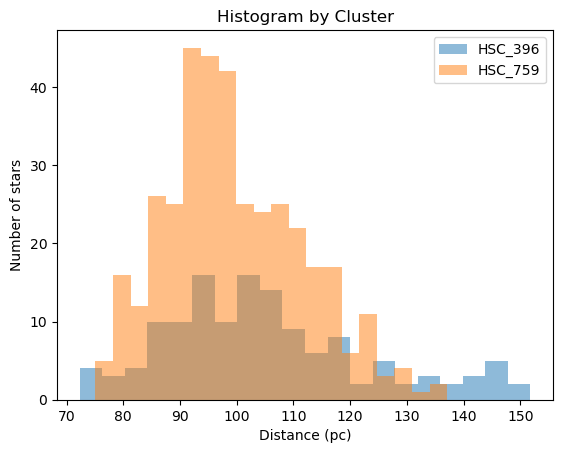

In [145]:
df2_analisis = df2_analisis[df2_analisis['Name'].isin(["HSC_396",'HSC_759'])]
for name, group in df2_analisis.groupby("Name"):
    plt.hist(1000/group["Plx"], bins=20, alpha=0.5, label=name)

plt.legend()
plt.xlabel("Distance (pc)")
plt.ylabel("Number of stars")
plt.title("Histogram by Cluster")
plt.savefig("../figures/histogram_parallax_HSC.png")
plt.show()

In [ ]:
radius_metrics

,Name,radio_mean,radio_median,radio_std,radius_effective
0,HSC_396,29.367811,25.441353,17.672011,25.441353
1,HSC_759,21.760564,18.072876,12.466444,18.072876
2,Melotte_111,15.421154,11.259414,11.240579,11.259414
3,Melotte_25,15.630937,11.381602,11.735655,11.381602


In [181]:
df2_analisis = df2_analisis.merge(df1[["source_id","cluster","fidelity_v2"]], left_on="GaiaDR3", right_on="source_id", how="left")


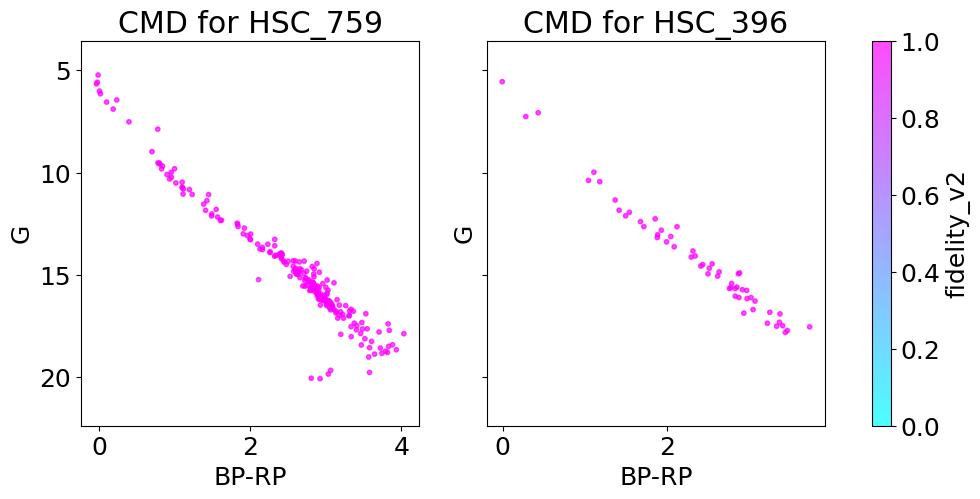

In [178]:
import matplotlib.colors as mcolors

plt.rcParams["font.size"] = 18
names = df2_analisis['Name'].unique()
n = len(names)

fig, axes = plt.subplots(1, n, figsize=(6 * n, 5), sharey=True)
axes = np.atleast_1d(axes)

norm = mcolors.Normalize(vmin=0, vmax=1, clip=True)

for ax, name in zip(axes, names):
    subset = df2_analisis[df2_analisis['Name'] == name]
    sc = ax.scatter(
        subset['BP-RP'],
        subset['Gmag'],
        c=np.clip(subset['fidelity_v2'], 0, 1),
        cmap='cool',
        norm=norm,
        s=10,
        alpha=0.7
    )
    ax.set_xlabel('BP-RP')
    ax.set_ylabel('G')
    ax.set_title(f"CMD for {name}")
    ax.set_ylim(subset['Gmag'].max() + 2, subset['Gmag'].min() - 2)

fig.colorbar(sc, ax=axes, label='fidelity_v2')
plt.savefig("../figures/scatter_BP_RP_G_HSC.png")
plt.show()

In [173]:
df2_analisis["fidelity_v2"].describe()

count    268.000000
mean       0.999448
std        0.006449
min        0.915039
25%        1.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: fidelity_v2, dtype: float64

In [183]:
df2_analisis["cluster"].value_counts()

cluster
-111.0    195
-12.0      55
-13.0      15
 7.0        3
Name: count, dtype: int64